# 1- Import Libraries

In [798]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score, roc_auc_score, roc_curve
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 2- Data Preparation

In [553]:
df = pd.read_csv('heart_failure.csv')

In [3]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [799]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical = list(df.dtypes[df.dtypes == 'object'].index)
for c in categorical:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [5]:
df.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,maxhr,exerciseangina,oldpeak,st_slope,heartdisease
0,40,m,ata,140,289,0,normal,172,n,0.0,up,0
1,49,f,nap,160,180,0,normal,156,n,1.0,flat,1
2,37,m,ata,130,283,0,st,98,n,0.0,up,0
3,48,f,asy,138,214,0,normal,108,y,1.5,flat,1
4,54,m,nap,150,195,0,normal,122,n,0.0,up,0


## 2-1 Data understanding

In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             918 non-null    int64  
 1   sex             918 non-null    object 
 2   chestpaintype   918 non-null    object 
 3   restingbp       918 non-null    int64  
 4   cholesterol     918 non-null    int64  
 5   fastingbs       918 non-null    int64  
 6   restingecg      918 non-null    object 
 7   maxhr           918 non-null    int64  
 8   exerciseangina  918 non-null    object 
 9   oldpeak         918 non-null    float64
 10  st_slope        918 non-null    object 
 11  heartdisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe().round(1)

,age,restingbp,cholesterol,fastingbs,maxhr,oldpeak,heartdisease
count,918.0,918.0,918.0,918.0,918.0,918.0,918.0
mean,53.5,132.4,198.8,0.2,136.8,0.9,0.6
std,9.4,18.5,109.4,0.4,25.5,1.1,0.5
min,28.0,0.0,0.0,0.0,60.0,-2.6,0.0
25%,47.0,120.0,173.2,0.0,120.0,0.0,0.0
50%,54.0,130.0,223.0,0.0,138.0,0.6,1.0
75%,60.0,140.0,267.0,0.0,156.0,1.5,1.0
max,77.0,200.0,603.0,1.0,202.0,6.2,1.0


## 2-2 Checking for missing values

In [ ]:
df.isna().sum()

,0
age,0
sex,0
chestpaintype,0
restingbp,0
cholesterol,0
fastingbs,0
restingecg,0
maxhr,0
exerciseangina,0
oldpeak,0


No missing values!

## 2-3 EDA

### 2-3-1 Correlation Matrix: Feature Importance for numerical variables

In [555]:
numeric = df.select_dtypes(include=['number']).columns
categorical = df.select_dtypes(include=['object']).columns

In [7]:
correlation = df[numeric].corr()
correlation

,age,restingbp,cholesterol,fastingbs,maxhr,oldpeak,heartdisease
age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
restingbp,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
fastingbs,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
maxhr,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
heartdisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


Ploting correlation matrix

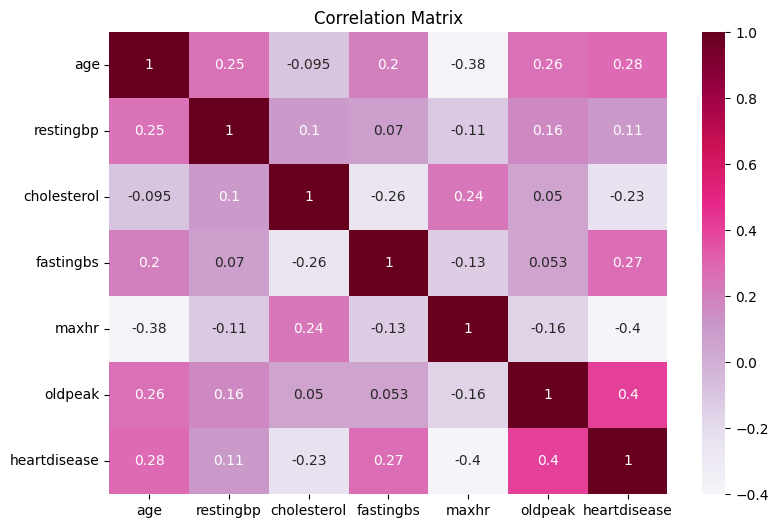

In [8]:
plt.figure(figsize=(9,6))
sns.heatmap(correlation, annot=True, cmap='PuRd')
plt.title('Correlation Matrix')
plt.show()



---


* We can clearly observe that feature 'oldpeak' has the highest correlation score with the target variable 'heartdisease'

### 2-3-2 Univariate Analysis



---


- Bar chart of the target variable

<Axes: xlabel='heartdisease', ylabel='count'>

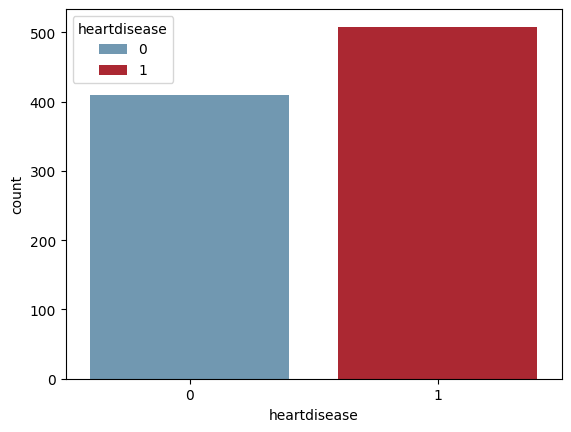

In [20]:
custom_color1 =["#669bbc", "#c1121f"]
sns.countplot(x = 'heartdisease', hue='heartdisease', data = df, palette=custom_color1)



---
- Number of patients suffering from heart failure exceeds those who do not.




---
- Chest pain type distribution


<Axes: xlabel='chestpaintype', ylabel='count'>

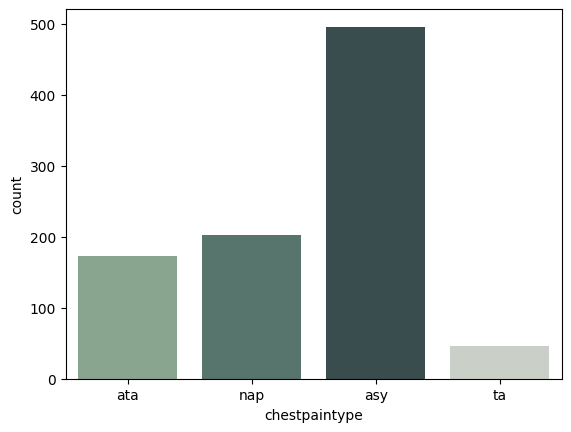

In [12]:
custom_color2 =["#84a98c","#52796f", "#354f52" ,"#cad2c5"]
sns.countplot(x = 'chestpaintype',hue='chestpaintype' ,data = df, palette=custom_color2)



---
- Pie chart of Gender distribution

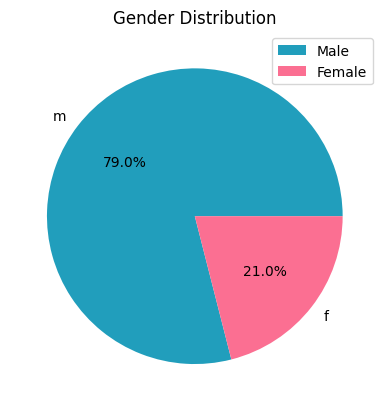

In [ ]:
custom_color3=["#219ebc","#fb6f92"]
plt.pie(df.sex.value_counts(), labels=df.sex.value_counts().index, autopct='%1.1f%%', colors=custom_color3)
xlabels = ['Male', 'Female']
plt.legend(xlabels)
plt.title('Gender Distribution')
plt.show()

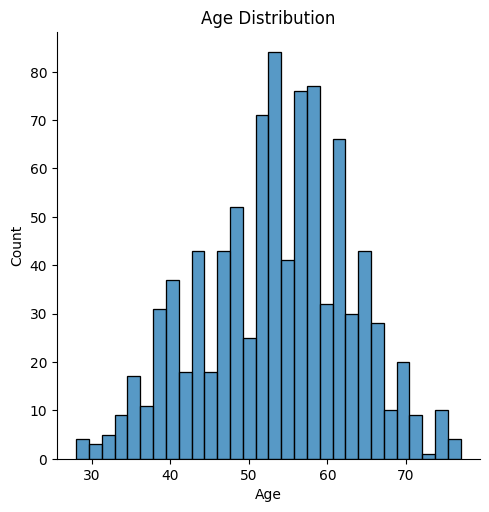

In [34]:
sns.displot(df, x='age', kde=False, bins=30)  # kde=False for histogram only

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()



---
- The highest number of patients suffering from heart disease falls within the age range of 50 to 65.


/tmp/ipython-input-3480751150.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='cholesterol', shade=True)


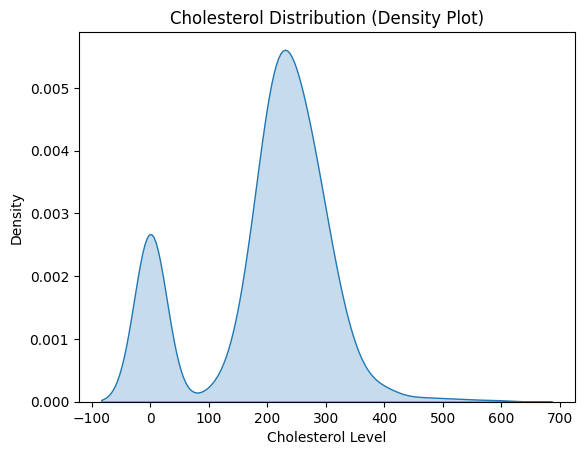

In [26]:
sns.kdeplot(data=df, x='cholesterol', shade=True)
plt.title('Cholesterol Distribution (Density Plot)')
plt.xlabel('Cholesterol Level')
plt.ylabel('Density')
plt.show()

### 2-3-3 Bivarite Anaslysis



---


- Distribution of "oldpeak feature" by "heartdisease" using boxplot shows the presences of outliers in the independant variable

<Axes: xlabel='heartdisease', ylabel='oldpeak'>

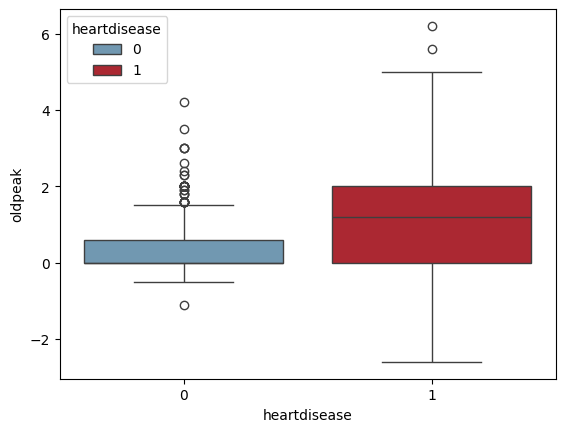

In [544]:
sns.boxplot(x='heartdisease', y='oldpeak',hue='heartdisease', data=df, palette=custom_color1)

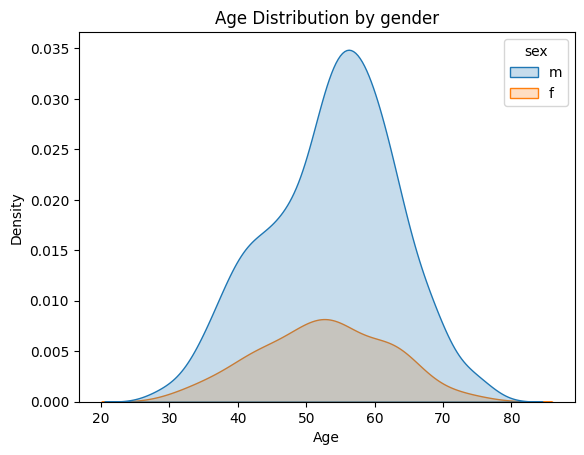

In [22]:
sns.kdeplot(data=df, x='age', hue='sex',fill=True)

plt.title('Age Distribution by gender')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()




---
- restinggecg ( resting electrocardiogram results)


<Axes: xlabel='restingecg', ylabel='count'>

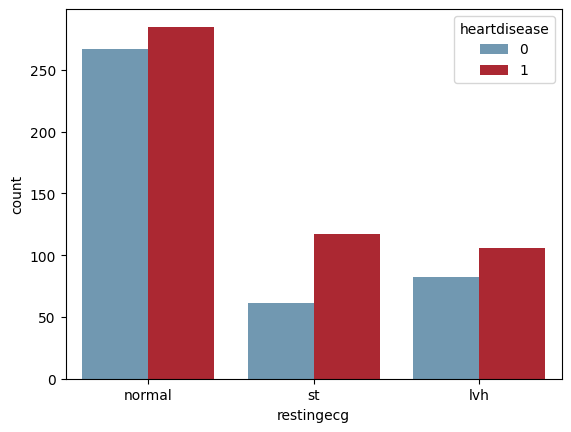

In [23]:
sns.countplot(x = 'restingecg',hue='heartdisease' ,data = df, palette=custom_color1)



---

- Distribution of feature st_slope by target variable heartdisease

<Axes: xlabel='st_slope', ylabel='count'>

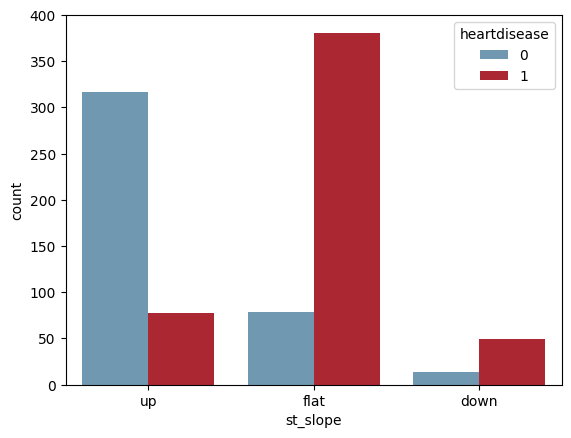

In [24]:
sns.countplot(x ='st_slope', hue='heartdisease', data=df, palette=custom_color1)

## 2-4 Setting up the validation framework

In [870]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [871]:
len(df_full_train), len(df_train), len(df_val), len(df_test)

(734, 550, 184, 184)

In [866]:
#to shuffle indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [872]:
#extracting target variable from each set
y_train = df_train.heartdisease.values
y_val = df_val.heartdisease.values
y_test = df_test.heartdisease.values

In [873]:
del df_train['heartdisease']
del df_val['heartdisease']
del df_test['heartdisease']

## 2-5 Feature Importance

### 2-5-1 Mutual Information: For categorical variables

In [808]:
#creating feature importance methodusing mutual information score
def mutual_info_heartdisease_score(series):
  return mutual_info_score(series, y_train)

In [809]:
mutual_info = df_train[categorical].apply(mutual_info_heartdisease_score)
mutual_info.sort_values(ascending=False)

,0
st_slope,0.195292
chestpaintype,0.136792
exerciseangina,0.135957
sex,0.053022
restingecg,0.002869


- **st_slope** is the most important feature among the categorical ones. - the

---
ST_Slope is about the shape of a certain part of the heart's electrical signal during exercise, called the ST segment. This part shows how the heart recovers after each beat.



## 2-6 One-hot-encoding

In [874]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X = dv.transform(val_dict)

# 2- Models Training

## 2-1 Baseline Model: Logistic Regression

In [811]:
lg_model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42) # C controls how much the model tries avoid overfitting
lg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

### 2-1-2 Parameter Tuning


`C regularization parameter `





In [812]:
C = [0.01, 0.1, 1, 10, 100]
best_auc = 0
best_C = None
for c in C:
  lg_model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
  lg_model.fit(X_train, y_train)

  y_pred_lg = lg_model.predict_proba(X)[:,1]
  y_pred_lg = (y_pred_lg >= 0.5).astype(int)

  auc = roc_auc_score(y_val, y_pred_lg)
  print(f"C:{c} , Accuracy: {auc:.4f}")
  if auc > best_auc:
    best_auc = auc
    best_C = c

print("Best C:", best_C)
print(f"Best AUC_score: {best_auc:.4f}")


C:0.01 , Accuracy: 0.8644
C:0.1 , Accuracy: 0.8884
C:1 , Accuracy: 0.8789
C:10 , Accuracy: 0.8789
C:100 , Accuracy: 0.8789
Best C: 0.1
Best AUC_score: 0.8884


`max_iter`

In [813]:
max_iter = [100, 200, 500, 800, 1000]
best_max_iter = None
for iter in max_iter:
  lg_model = LogisticRegression(solver='liblinear', C=0.1, max_iter=iter, random_state=4)
  lg_model.fit(X_train, y_train)

  y_pred_lg = lg_model.predict_proba(X)[:,1]
  y_pred_lg = (y_pred_lg >= 0.5).astype(int)

  auc = roc_auc_score(y_val, y_pred_lg)
  print(f"max_iter:{iter} , AUC_score: {auc:.4f}")


max_iter:100 , AUC_score: 0.8884
max_iter:200 , AUC_score: 0.8884
max_iter:500 , AUC_score: 0.8884
max_iter:800 , AUC_score: 0.8884
max_iter:1000 , AUC_score: 0.8884




---
* All values of max_iter delievers the same accuracy score so we'll go for 1000


In [815]:
#final tuned model
lg_model = LogisticRegression(solver='liblinear', C=0.1, max_iter=1000, random_state=1)
lg_model.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=1, solver='liblinear')

###2-1-1 Evaluation: Logistic Regression:
Confusion Matrix ( optional step, this is required for imbalaned classification)

[[ 65  13]
 [  6 100]]


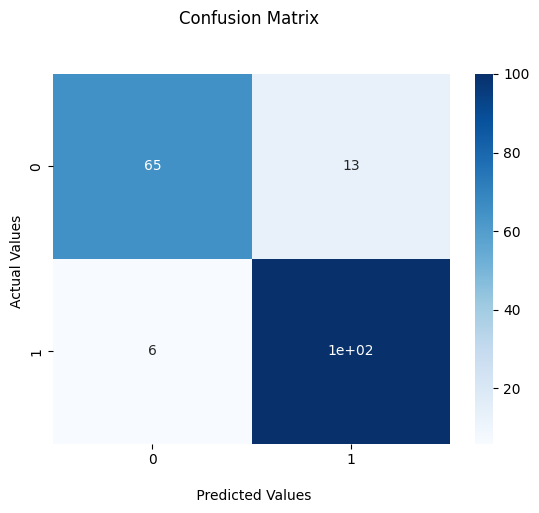

In [816]:
cm = confusion_matrix(y_val, y_pred_lg)
print (cm)
tn, fp, fn, tp = cm.ravel()
ax=sns.heatmap(cm, annot=True,cmap='Blues')
ax.set_title('Confusion Matrix \n\n');
ax.set_xlabel('\n Predicted Values')
ax.set_ylabel('Actual Values ');

In [298]:
print(classification_report(y_val,y_pred_lg))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        78
           1       0.88      0.92      0.90       106

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## 2-2 Random Forest Classifier

In [875]:
rf_model = RandomForestClassifier(n_estimators=10, random_state=1, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=1)

### 2-2-1 Parameter Tuning

`n_estimators`  

Number of decision trees in the forest

In [876]:
n_estimators = range(10, 210, 10)# from 10 to 200 with 10 steps
for n in n_estimators:
  rf_model = RandomForestClassifier(n_estimators=n, random_state=1, n_jobs=-1)
  rf_model.fit(X_train, y_train)

  y_pred_rf= rf_model.predict_proba(X)[:,1]
  y_pred_rf = (y_pred_rf >= 0.5).astype(int)

  auc = roc_auc_score(y_val, y_pred_rf)
  print(f"n_estimators:{n}, AUC_score {auc:.4f}")

n_estimators:10, AUC_score 0.9123
n_estimators:20, AUC_score 0.8948
n_estimators:30, AUC_score 0.9106
n_estimators:40, AUC_score 0.8948
n_estimators:50, AUC_score 0.9042
n_estimators:60, AUC_score 0.8995
n_estimators:70, AUC_score 0.8948
n_estimators:80, AUC_score 0.8995
n_estimators:90, AUC_score 0.9042
n_estimators:100, AUC_score 0.8995
n_estimators:110, AUC_score 0.8995
n_estimators:120, AUC_score 0.8995
n_estimators:130, AUC_score 0.8995
n_estimators:140, AUC_score 0.8995
n_estimators:150, AUC_score 0.8995
n_estimators:160, AUC_score 0.9059
n_estimators:170, AUC_score 0.8995
n_estimators:180, AUC_score 0.8995
n_estimators:190, AUC_score 0.8995
n_estimators:200, AUC_score 0.8995




---
* best n_estimators is 10


`max_depth`

Maximum depth of each tree -> Limits overfitting

In [878]:
max_depth = range(1,21,1)
for d in max_depth:
  rf_model = RandomForestClassifier(n_estimators=10, max_depth=d, random_state=1)
  rf_model.fit(X_train, y_train)

  y_pred_rf= rf_model.predict_proba(X)[:,1]
  y_pred_rf = (y_pred_rf >= 0.5).astype(int)

  auc= roc_auc_score(y_val, y_pred_rf)
  print(f"max_depth:{d}, AUC_score: {auc:.4f}")

max_depth:1, AUC_score: 0.8661
max_depth:2, AUC_score: 0.8759
max_depth:3, AUC_score: 0.8867
max_depth:4, AUC_score: 0.8961
max_depth:5, AUC_score: 0.8914
max_depth:6, AUC_score: 0.9012
max_depth:7, AUC_score: 0.8901
max_depth:8, AUC_score: 0.8850
max_depth:9, AUC_score: 0.8884
max_depth:10, AUC_score: 0.8739
max_depth:11, AUC_score: 0.8965
max_depth:12, AUC_score: 0.8803
max_depth:13, AUC_score: 0.9012
max_depth:14, AUC_score: 0.9123
max_depth:15, AUC_score: 0.9123
max_depth:16, AUC_score: 0.9123
max_depth:17, AUC_score: 0.9123
max_depth:18, AUC_score: 0.9123
max_depth:19, AUC_score: 0.9123
max_depth:20, AUC_score: 0.9123


* We choose max_depth 12 because when I tested the model later depth_max > 15 caused mismatch prediction

`min_samples_leaf`

the minimum number of samples required to be at a leaf node

In [884]:
min_samples_leaf = range(1,21,2)
for leaf in min_samples_leaf:
  rf_model = RandomForestClassifier(n_estimators=10, max_depth=13,min_samples_leaf=leaf, random_state=1)
  rf_model.fit(X_train, y_train)

  y_pred_rf= rf_model.predict_proba(X)[:,1]
  y_pred_rf = (y_pred_rf >= 0.5).astype(int)

  auc = roc_auc_score(y_val, y_pred_rf)
  print(f"min_samples_leaf:{leaf}, AUC_score: {auc:.4f}")

min_samples_leaf:1, AUC_score: 0.9012
min_samples_leaf:3, AUC_score: 0.8820
min_samples_leaf:5, AUC_score: 0.8931
min_samples_leaf:7, AUC_score: 0.8725
min_samples_leaf:9, AUC_score: 0.8884
min_samples_leaf:11, AUC_score: 0.8931
min_samples_leaf:13, AUC_score: 0.8965
min_samples_leaf:15, AUC_score: 0.8897
min_samples_leaf:17, AUC_score: 0.8786
min_samples_leaf:19, AUC_score: 0.8597


* We select min_samples_leaf equal to 1

In [885]:
#Final tuned model
rf_model = RandomForestClassifier(n_estimators=10,min_samples_leaf=1,max_depth=13, random_state=1, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf= rf_model.predict_proba(X)[:,1]
y_pred_rf = (y_pred_rf >= 0.5).astype(int)

[[ 67  11]
 [  6 100]]


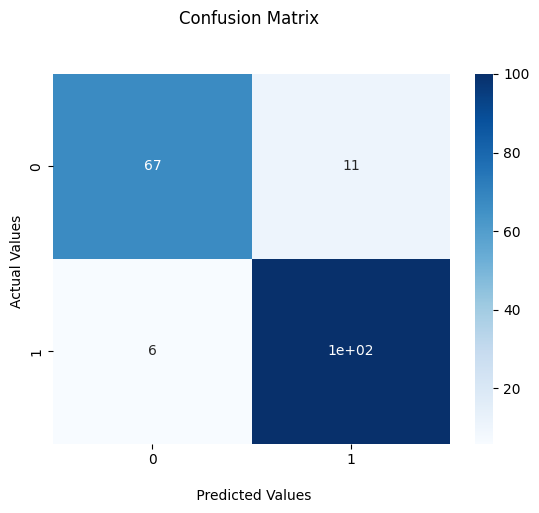

In [886]:
cm = confusion_matrix(y_val, y_pred_rf)
print (cm)
tn, fp, fn, tp = cm.ravel()
ax=sns.heatmap(cm, annot=True,cmap='Blues')
ax.set_title('Confusion Matrix \n\n');
ax.set_xlabel('\n Predicted Values')
ax.set_ylabel('Actual Values ');

* **Interpretation**: In terms of recall, the model's performance is good, as it correctly identified 98 patients who have heart disease. However, it misclassified 8 patients who actually have heart disease as negative, meaning it predicted they do not suffer from heart failure. Also, the precision shows similar results. Overall, model is performing well on the validation set

## 2-3 XGBoost Classifier

In [887]:
xgb_model = XGBClassifier(eta=0.1, max_depth=3,min_child_weight=1)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

### 2-3-1 Parameter Tuning

`eta`

In [824]:
eta = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
for e in eta:
  xgb_model = XGBClassifier(eta=e, max_depth=3,min_child_weight=1)
  xgb_model.fit(X_train, y_train)

  y_pred_xgb = xgb_model.predict_proba(X)[:,1]
  y_pred_xgb = (y_pred_xgb >= 0.5).astype(int)

  auc = roc_auc_score(y_val, y_pred_xgb)
  print(f"eta:{e}, AUC_score: {auc:.4f}")

eta:0.01, AUC_score: 0.9072
eta:0.1, AUC_score: 0.9059
eta:0.2, AUC_score: 0.9012
eta:0.3, AUC_score: 0.8948
eta:0.4, AUC_score: 0.8742
eta:0.5, AUC_score: 0.8725


- We go for eta = 0.01

`max_depth`

In [825]:
max_depth = range(1,10,1)
for d in max_depth:
  xgb_model = XGBClassifier(eta=0.01, max_depth=d, min_child_weight=1)
  xgb_model.fit(X_train, y_train)

  y_pred_xgb= rf_model.predict_proba(X)[:,1]
  y_pred_xgb= (y_pred_xgb >= 0.5).astype(int)

  auc= roc_auc_score(y_val, y_pred_xgb)
  print(f"max_depth:{d}, AUC_score: {auc:.4f}")

max_depth:1, AUC_score: 0.9123
max_depth:2, AUC_score: 0.9123
max_depth:3, AUC_score: 0.9123
max_depth:4, AUC_score: 0.9123
max_depth:5, AUC_score: 0.9123
max_depth:6, AUC_score: 0.9123
max_depth:7, AUC_score: 0.9123
max_depth:8, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123


* We will go for max_depth equals to 6

In [827]:
min_child_weight = range(1,10,1)
for m in max_depth:
  xgb_model = XGBClassifier(eta=0.01, max_depth=6, min_child_weight=m)
  xgb_model.fit(X_train, y_train)

  y_pred_xgb= rf_model.predict_proba(X)[:,1]
  y_pred_xgb= (y_pred_xgb >= 0.5).astype(int)

  auc= roc_auc_score(y_val, y_pred_xgb)
  print(f"max_depth:{d}, AUC_score: {auc:.4f}")

max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123
max_depth:9, AUC_score: 0.9123


In [888]:
#final tuned xgb model
xgb_model = XGBClassifier(eta=0.01, max_depth=6,min_child_weight=1)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.01, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

[[ 66  12]
 [  5 101]]


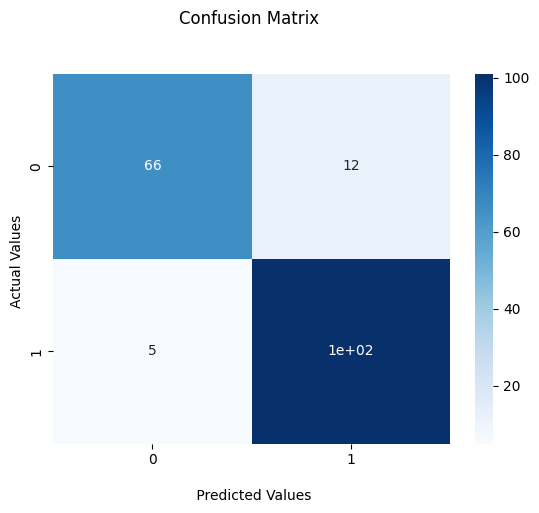

In [889]:
cm = confusion_matrix(y_val, y_pred_xgb)
print (cm)
tn, fp, fn, tp = cm.ravel()
ax=sns.heatmap(cm, annot=True,cmap='Blues')
ax.set_title('Confusion Matrix \n\n');
ax.set_xlabel('\n Predicted Values')
ax.set_ylabel('Actual Values ');

# 3- Selecting the final model

## 3-1 Tuned Logistic Regression

In [830]:
lg_model = LogisticRegression(solver='liblinear', C=0.1, max_iter=1000, random_state=42)
lg_model.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='liblinear')

In [831]:
y_pred_lg = lg_model.predict_proba(X)[:,1]
y_pred_lg = (y_pred_lg >= 0.5).astype(int)
accuracy = accuracy_score(y_val, y_pred_lg)
print("Accuracy:", accuracy)

Accuracy: 0.8967391304347826


In [832]:
auc_lg = roc_auc_score(y_val, y_pred_lg)
print("AUC score:", auc_lg)

AUC score: 0.8883647798742138


## 3-2 Tuned Random Forest Classifier

In [891]:
rf_model = RandomForestClassifier(n_estimators=10,max_depth=13 ,min_samples_leaf=1, random_state=1, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=13, n_estimators=10, n_jobs=-1, random_state=1)

In [892]:
y_pred_rf= rf_model.predict_proba(X)[:,1]
y_pred_rf = (y_pred_rf >= 0.5).astype(int)
accuracy = accuracy_score(y_val, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.907608695652174


In [893]:
auc_rf = roc_auc_score(y_val, y_pred_rf)
print("AUC score:", auc_rf)

AUC score: 0.9011852926947267


## 3-3 Tuned XGBoost

In [894]:
xgb_model = XGBClassifier(eta=0.1, max_depth=6 ,min_child_weight=1, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)

In [895]:
y_pred_xgb = xgb_model.predict_proba(X)[:,1]
y_pred_xgb = (y_pred_xgb >= 0.5).astype(int)

accuracy = accuracy_score(y_val, y_pred_xgb)
print("Accuracy:", accuracy)

Accuracy: 0.907608695652174


In [896]:
auc_xgb = roc_auc_score(y_val, y_pred_xgb)
print("AUC score:", auc_xgb)

AUC score: 0.8994920174165457


# 4- Training the final model

## 4-1 Training

In [910]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [911]:
def train(df_train, y_train):
  train_dicts = df_train.to_dict(orient='records')

  dv = DictVectorizer(sparse=False)
  X_train = dv.fit_transform(train_dicts)

  model = RandomForestClassifier(n_estimators=10,
                                    max_depth=12,
                                    random_state=1,
                                    n_jobs=-1)
  model.fit(X_train, y_train)

  return dv, model

In [912]:
def predict(df, dv, model):
  dicts = df.to_dict(orient='records')
  X = dv.transform(dicts)
  y_pred = model.predict_proba(X)[:, 1]
  return y_pred

## 4-2 Evaluation: Cross Validation

In [913]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

auc_scores_rf = []

for train_idx, val_idx in kfold.split(df_full_train):
  df_train = df_full_train.iloc[train_idx]
  df_val = df_full_train.iloc[val_idx]

  y_train = df_train['heartdisease']
  y_val = df_val['heartdisease']

  df_train = df_train.drop('heartdisease', axis=1) #if we don't delete target variables from df_train
  df_val = df_val.drop('heartdisease', axis=1) #and df_val, model can accidentely use it as a feature, this also can lead to overfitting (auc scores = 1)

  dv, rf_model = train(df_train, y_train)
  y_pred_rf = predict(df_val, dv, rf_model)

  auc= roc_auc_score(y_val, y_pred_rf)
  auc_scores_rf.append(auc)

In [914]:
auc_scores_rf

[np.float64(0.9221466364323507),
 np.float64(0.8915216586449464),
 np.float64(0.9154214559386973),
 np.float64(0.9313104988830975),
 np.float64(0.9040346907993967)]

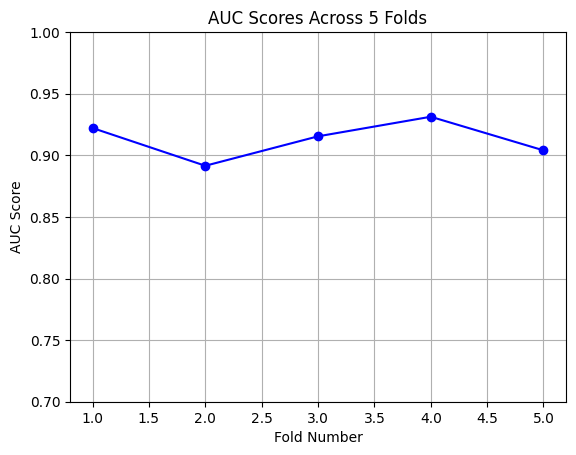

In [915]:
plt.plot(range(1, 6), auc_scores_rf, marker='o', linestyle='-', color='b')
plt.title('AUC Scores Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('AUC Score')
plt.ylim([0.7, 1.0])
plt.grid(True)
plt.show()

In [916]:
df_full_train.reset_index(drop=True, inplace=True)
df_full_train.head(4)

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,maxhr,exerciseangina,oldpeak,st_slope,heartdisease
0,42,m,nap,120,240,1,normal,194,n,0.8,down,0
1,36,m,nap,130,209,0,normal,178,n,0.0,up,0
2,56,m,asy,150,213,1,normal,125,y,1.0,flat,1
3,37,f,nap,130,211,0,normal,142,n,0.0,up,0


## 4-3 Testing

In [917]:
y_full_train = df_full_train['heartdisease']
y_test = df_test.heartdisease.values

df_full_train = df_full_train.drop('heartdisease', axis=1)
dv, model = train(df_full_train, y_full_train)
y_pred = predict(df_test, dv, model)

auc_test = roc_auc_score(y_test, y_pred)
print(auc_test)

0.9176477727879597


In [918]:
dv, model

(DictVectorizer(sparse=False),
 RandomForestClassifier(max_depth=12, n_estimators=10, n_jobs=-1, random_state=1))

In [919]:
patient = df_test.iloc[2]
X = dv.transform([patient.to_dict()])
pred_patient = model.predict_proba(X)[0,1]
print(f'Heart Disease Probability of this patient is: {pred_patient:.4f}')


Heart Disease Probability of this patient is: 0.9500
